In [1]:
import pandas as pd
from textblob import TextBlob


In [2]:
df=pd.read_csv('Reviews.csv',nrows=5000)
df.shape

(5000, 10)

### Display frist 10 rows of data

In [3]:
df.head(10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


### Total row and columns

In [4]:
df.shape


(5000, 10)

In [5]:
df.isnull()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isna().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [7]:
df=df.dropna()

In [8]:
df.isna().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [9]:
df.shape
df.duplicated().sum()

np.int64(0)

In [10]:
print(df.duplicated(subset=['UserId','Text']).sum())

16


In [11]:
df = df.drop_duplicates()
df.shape

(5000, 10)

In [12]:
print(df.duplicated(subset=['UserId', 'Text']).sum())


16


In [13]:

df = df.drop_duplicates(subset=['UserId',  'Text'], keep='first')

In [14]:
df.shape

(4984, 10)

In [15]:
print(df.duplicated(subset=['UserId','Text']).sum())

0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [18]:
df=df[['Text','Score']]

In [19]:
df

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5
...,...,...
4995,I really wanted to like these.<br /><br />Firs...,2
4996,I was not impressed with these cookies when I ...,1
4997,The cookies came sealed and seem to be high qu...,3
4998,"These taste very good, but aren't like the BES...",4


In [32]:
def get_sentiment(text):
    analysis = TextBlob(str(text))
    polarity = analysis.sentiment.polarity  
    
    if polarity > 0.2:
        return 'Positive'
    elif polarity < 0.1:
        return 'Negative'
    else:
        return 'Neutral'
get_sentiment('text')

 

'Negative'

In [33]:
df['Sentiment_Analysis'] = df['Text'].apply(get_sentiment)
df['Sentiment_Analysis']

0       Positive
1       Negative
2        Neutral
3        Neutral
4       Positive
          ...   
4995    Negative
4996    Positive
4997    Positive
4998    Positive
4999     Neutral
Name: Sentiment_Analysis, Length: 4984, dtype: object

In [34]:
def get_polarity(Text):
    return TextBlob(str(Text)).sentiment.polarity
df['Polarity_score']=df['Text'].apply(get_polarity)
# df['Polarity_score','Sentiment'].head(20)
print(df)


                                                   Text  Score  \
0     I have bought several of the Vitality canned d...      5   
1     Product arrived labeled as Jumbo Salted Peanut...      1   
2     This is a confection that has been around a fe...      4   
3     If you are looking for the secret ingredient i...      2   
4     Great taffy at a great price.  There was a wid...      5   
...                                                 ...    ...   
4995  I really wanted to like these.<br /><br />Firs...      2   
4996  I was not impressed with these cookies when I ...      1   
4997  The cookies came sealed and seem to be high qu...      3   
4998  These taste very good, but aren't like the BES...      4   
4999  I love these cookies. I am on the paleo diet r...      5   

     Sentiment_Analysis  Polarity_score  
0              Positive        0.450000  
1              Negative       -0.033333  
2               Neutral        0.133571  
3               Neutral        0.166667

In [50]:
import matplotlib.pyplot as plt

In [42]:
Sentiment_percent=df["Sentiment_Analysis"].value_counts(normalize=True)*100
print(Sentiment_percent)

Sentiment_Analysis
Positive    58.266453
Negative    22.813002
Neutral     18.920546
Name: proportion, dtype: float64


<Axes: ylabel='proportion'>

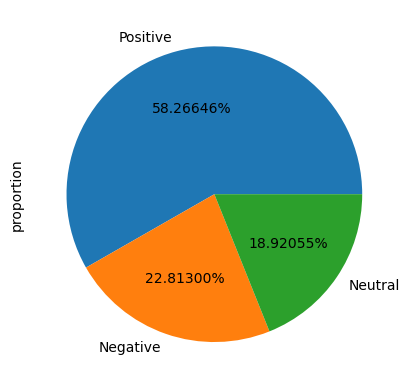

In [44]:
Sentiment_percent.plot(kind="pie", autopct="%1.5f%%")

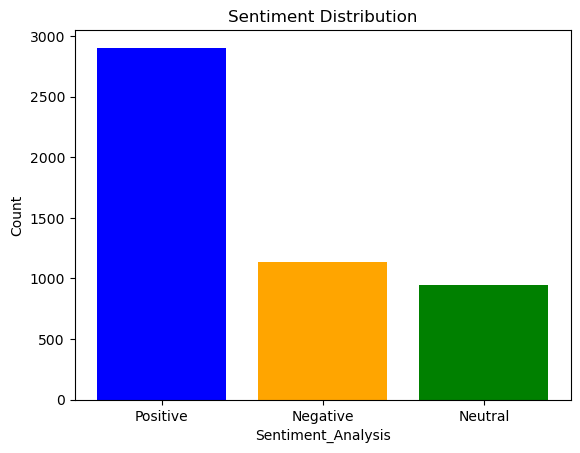

In [68]:
counts=df["Sentiment_Analysis"].value_counts()
colors = ["blue", "orange", "green"]
plt.bar(counts.index, counts.values, color=colors)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment_Analysis")
plt.ylabel("Count")

plt.show()

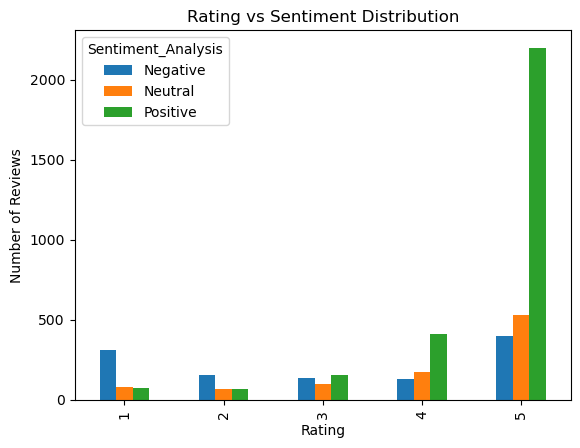

In [76]:
ct = pd.crosstab(df["Score"],df["Sentiment_Analysis"])

ct.plot(kind="bar")

plt.title("Rating vs Sentiment Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

## Insights & Summary

Based on the sentiment analysis of 5,000 Amazon Fine Food Reviews using 
TextBlob, approximately **58.27%** of the reviews were Positive, **22.81%** 
were Negative, and **18.92%** were Neutral. This clearly shows that the 
majority of customers are satisfied with the food products they purchased 
on Amazon.

In the Negative reviews, customers mostly complained about issues like 
**poor taste, misleading product descriptions, bad packaging, and 
short expiry dates**. Words like *"disappointed"*, *"terrible"*, *"waste"*, 
and *"not fresh"* appeared frequently in negative feedback.

One surprising finding was that nearly **1 in 5 reviews (18.92%)** were 
Neutral — meaning customers were neither happy nor unhappy. This is an 
overlooked segment that businesses often ignore but could be converted 
into Positive experiences with small improvements.

**Business Recommendation:** Since 22.81% reviews are Negative, the company 
should focus on improving **product freshness, packaging quality, and accurate 
product descriptions** on their Amazon listings. Targeting the 18.92% Neutral 
customers with better after-sales support and follow-up could also help 
convert them into loyal, satisfied customers.

In [79]:
df

,Text,Score,Sentiment_Analysis,Polarity_score
0,I have bought several of the Vitality canned d...,5,Positive,0.450000
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative,-0.033333
2,This is a confection that has been around a fe...,4,Neutral,0.133571
3,If you are looking for the secret ingredient i...,2,Neutral,0.166667
4,Great taffy at a great price. There was a wid...,5,Positive,0.483333
...,...,...,...,...
4995,I really wanted to like these.<br /><br />Firs...,2,Negative,-0.083333
4996,I was not impressed with these cookies when I ...,1,Positive,0.302273
4997,The cookies came sealed and seem to be high qu...,3,Positive,0.354615
4998,"These taste very good, but aren't like the BES...",4,Positive,0.345417


In [80]:
df=df.head(4984)

In [81]:
df

,Text,Score,Sentiment_Analysis,Polarity_score
0,I have bought several of the Vitality canned d...,5,Positive,0.450000
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative,-0.033333
2,This is a confection that has been around a fe...,4,Neutral,0.133571
3,If you are looking for the secret ingredient i...,2,Neutral,0.166667
4,Great taffy at a great price. There was a wid...,5,Positive,0.483333
...,...,...,...,...
4995,I really wanted to like these.<br /><br />Firs...,2,Negative,-0.083333
4996,I was not impressed with these cookies when I ...,1,Positive,0.302273
4997,The cookies came sealed and seem to be high qu...,3,Positive,0.354615
4998,"These taste very good, but aren't like the BES...",4,Positive,0.345417


In [83]:
df.to_csv("Reviews.csv", index=False)

In [84]:
df

,Text,Score,Sentiment_Analysis,Polarity_score
0,I have bought several of the Vitality canned d...,5,Positive,0.450000
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative,-0.033333
2,This is a confection that has been around a fe...,4,Neutral,0.133571
3,If you are looking for the secret ingredient i...,2,Neutral,0.166667
4,Great taffy at a great price. There was a wid...,5,Positive,0.483333
...,...,...,...,...
4995,I really wanted to like these.<br /><br />Firs...,2,Negative,-0.083333
4996,I was not impressed with these cookies when I ...,1,Positive,0.302273
4997,The cookies came sealed and seem to be high qu...,3,Positive,0.354615
4998,"These taste very good, but aren't like the BES...",4,Positive,0.345417
